# Exploring motor data
This script only estimates the effective mass of the motor shaft but also...
- analyzes the noisiness of the data
- tries different smoothing effects on positional data to extract acceleration

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

## Functions

In [2]:
# ---------------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------------
DATA_DIR = "mass_estimation_data"


def load_trial_index(data_dir=DATA_DIR):
    """Load the trial index file and return a DataFrame of trial metadata."""
    index_path = os.path.join(data_dir, "trial_index.npz")
    idx = np.load(index_path, allow_pickle=True)
    df = pd.DataFrame({
        "trial_num": idx["trial_nums"],
        "force_commanded_mN": idx["forces_mN"],
        "iteration": idx["iterations"],
        "n_samples": idx["n_samples"],
        "filename": idx["filenames"],
    })
    return df


def load_trial(filename, data_dir=DATA_DIR):
    """Load a single trial .npz file and return a DataFrame."""
    path = os.path.join(data_dir, filename)
    data = np.load(path, allow_pickle=True)

    n = len(data["t_stream"])
    df = pd.DataFrame({
        "t_stream": data["t_stream"][:n],
        "t_accel": data["t_accel"][:n],
        "position_um": data["position_um"][:n],
        "force_mN": data["force_mN"][:n],
        "accel_mmpss": data["accel_mmpss"][:n],
    })
    # Make time relative to trial start
    t0 = df["t_stream"].iloc[0]
    df["t_stream_s"] = df["t_stream"] - t0
    df["t_accel_s"] = df["t_accel"] - t0
    df["force_commanded_mN"] = int(data["force_commanded_mN"])
    return df


def load_all_trials(data_dir=DATA_DIR):
    """Load every trial into a dict keyed by trial_num."""
    index = load_trial_index(data_dir)
    trials = {}
    for _, row in index.iterrows():
        tnum = row["trial_num"]
        trials[tnum] = load_trial(row["filename"], data_dir)
        trials[tnum]["trial_num"] = tnum
    return index, trials


In [3]:
# ---------------------------------------------------------------------------
# Plotting functions
# ---------------------------------------------------------------------------

def plot_single_trial(trial_df, title_suffix=""):
    """Plot position, force, and acceleration vs time for one trial."""
    fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

    axes[0].plot(trial_df["t_stream_s"], trial_df["position_um"], "b-", linewidth=0.8)
    axes[0].set_ylabel("Position (µm)")
    axes[0].set_title(f"Trial Data {title_suffix}")
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(trial_df["t_stream_s"], trial_df["force_mN"], "r-", linewidth=0.8)
    axes[1].set_ylabel("Force (mN)")
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(trial_df["t_accel_s"], trial_df["accel_mmpss"], "g-", linewidth=0.8)
    axes[2].set_ylabel("Acceleration (mm/s²)")
    axes[2].set_xlabel("Time (s)")
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    return fig


def plot_by_trial_numbers(trials, trial_nums, field="position_um"):
    """Overlay a chosen field for selected trial numbers."""
    fig, ax = plt.subplots(figsize=(10, 5))
    for tnum in trial_nums:
        df = trials[tnum]
        t_col = "t_accel_s" if field == "accel_mmpss" else "t_stream_s"
        label = f"Trial {tnum} ({df['force_commanded_mN'].iloc[0]} mN)"
        ax.plot(df[t_col], df[field], linewidth=0.8, label=label)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel(field)
    ax.set_title(f"{field} by trial")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    return fig


def plot_by_force(index, trials, force_mN, field="position_um"):
    """Overlay a chosen field for all trials at a given force level."""
    matching = index[index["force_commanded_mN"] == force_mN]
    trial_nums = matching["trial_num"].tolist()
    fig = plot_by_trial_numbers(trials, trial_nums, field=field)
    fig.axes[0].set_title(f"{field} — Force = {force_mN} mN")
    return fig


def plot_accel_vs_position(trials, trial_nums=None, force_mN=None):
    """Plot acceleration vs position (useful for mass estimation)."""
    fig, ax = plt.subplots(figsize=(10, 5))
    # Select trials
    if trial_nums is None:
        trial_nums = list(trials.keys())
    for tnum in trial_nums:
        df = trials[tnum]
        if force_mN is not None and df["force_commanded_mN"].iloc[0] != force_mN:
            continue
        label = f"Trial {tnum} ({df['force_commanded_mN'].iloc[0]} mN)"
        ax.plot(df["position_um"], df["accel_mmpss"], ".", markersize=2, label=label)
    ax.set_xlabel("Position (µm)")
    ax.set_ylabel("Acceleration (mm/s²)")
    ax.set_title("Acceleration vs Position")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    return fig


def plot_summary_stats(index, trials):
    """Bar chart of mean acceleration per force level."""
    records = []
    for _, row in index.iterrows():
        df = trials[row["trial_num"]]
        records.append({
            "force_commanded_mN": row["force_commanded_mN"],
            "mean_accel": df["accel_mmpss"].mean(),
            "trial_num": row["trial_num"],
        })
    summary = pd.DataFrame(records)
    grouped = summary.groupby("force_commanded_mN")["mean_accel"].agg(["mean", "std"])

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(grouped.index.astype(str), grouped["mean"], yerr=grouped["std"],
           capsize=5, color="steelblue", edgecolor="black")
    ax.set_xlabel("Commanded Force (mN)")
    ax.set_ylabel("Mean Acceleration (mm/s²)")
    ax.set_title("Mean Acceleration by Force Level")
    ax.grid(True, alpha=0.3, axis="y")
    plt.tight_layout()
    return fig

In [11]:
def plot_numerical_accelerations(index, trials, force_mN):
    """Calculate and plot the acceleration (second derivative of position)
    for each trial of a given commanded force. Return resulting acceleration estimates."""
    matching = index[index["force_commanded_mN"] == force_mN]
    trial_nums = matching["trial_num"].tolist()

    fig, ax = plt.subplots(figsize=(10, 5))
    results = {}

    for tnum in trial_nums:
        df = trials[tnum]
        if force_mN is not None and df["force_commanded_mN"].iloc[0] != force_mN:
            continue

        t = df["t_stream_s"].values
        pos = df["position_um"].values.astype(np.float64)

        # First derivative (velocity) via central differences
        dt = np.diff(t)
        vel = np.diff(pos) / dt  # µm/s
        # Midpoint times for velocity
        t_vel = 0.5 * (t[:-1] + t[1:])

        # Second derivative (acceleration) via central differences on velocity
        dt2 = np.diff(t_vel)
        accel = np.diff(vel) / dt2  # µm/s²
        t_accel = 0.5 * (t_vel[:-1] + t_vel[1:])

        # Convert µm/s² -> mm/s² for consistency with accel_mmpss
        accel_mmpss = accel / 1000.0

        ax.plot(t_accel, accel_mmpss, linewidth=0.8, label=f"Trial {tnum}")
        results[tnum] = {"t": t_accel, "accel_mmpss": accel_mmpss}

    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Numerical Acceleration (mm/s²)")
    ax.set_title(f"Numerical d²pos/dt² — Force = {force_mN} mN")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    return results, fig


def plot_savgol_data(index, trials, force_mN, window=11, order=2, derivative=0):
    """Calculate and plot the savgol-filtered positions for each trial of a
    given commanded force. Return the filtered outputs."""
    ylabel = "um"
    if derivative == 0:
        ylabel = "Position (um)"
    if derivative == 1:
        ylabel = "Velocity (um/s)"
    elif derivative == 2:
        ylabel = "Acceleration (mm/s^2)"
    else:
        assert ValueError("Derivative must be 0, 1, or 2")
    
    matching = index[index["force_commanded_mN"] == force_mN]
    trial_nums = matching["trial_num"].tolist()
    
    fig, ax = plt.subplots(figsize=(10, 5))
    results = {}

    for tnum in trial_nums:
        df = trials[tnum]
        if force_mN is not None and df["force_commanded_mN"].iloc[0] != force_mN:
            continue
        t = df["t_stream_s"].values
        pos = df["position_um"].values.astype(np.float64)

        # Sav gol needs average dt for filtering derivatives
        dt = np.mean(np.diff(t))
        filtered = savgol_filter(pos, window_length=window, polyorder=order,
                                 deriv=derivative, delta=dt)
        if derivative == 2:
            filtered = filtered / 1000.0
        ax.plot(t, filtered, linewidth=0.8, label=f"Trial {tnum}")
        results[tnum] = {"t": t, ylabel.split(" ")[0] + "_filtered": filtered}

    ax.set_xlabel("Time (s)")
    ax.set_ylabel(ylabel)
    ax.set_title(f"Savitzky-Golay Position (window={window}, order={order}) — Force = {force_mN} mN")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    return results, fig

## Plots

In [5]:
print("Loading data...")
index, trials = load_all_trials()
print(f"Loaded {len(trials)} trials.")
print(index.to_string(index=False))

Loading data...
Loaded 20 trials.
 trial_num  force_commanded_mN  iteration  n_samples                           filename
         1                7500          0        466  trial_001_force_7500mN_iter_0.npz
         2                7500          1        377  trial_002_force_7500mN_iter_1.npz
         3                7500          2        403  trial_003_force_7500mN_iter_2.npz
         4                7500          3        362  trial_004_force_7500mN_iter_3.npz
         5                7500          4        170  trial_005_force_7500mN_iter_4.npz
         6               10000          0        113 trial_006_force_10000mN_iter_0.npz
         7               10000          1        416 trial_007_force_10000mN_iter_1.npz
         8               10000          2        589 trial_008_force_10000mN_iter_2.npz
         9               10000          3        152 trial_009_force_10000mN_iter_3.npz
        10               10000          4        125 trial_010_force_10000mN_iter_4.np

In [ ]:
trials[1].columns

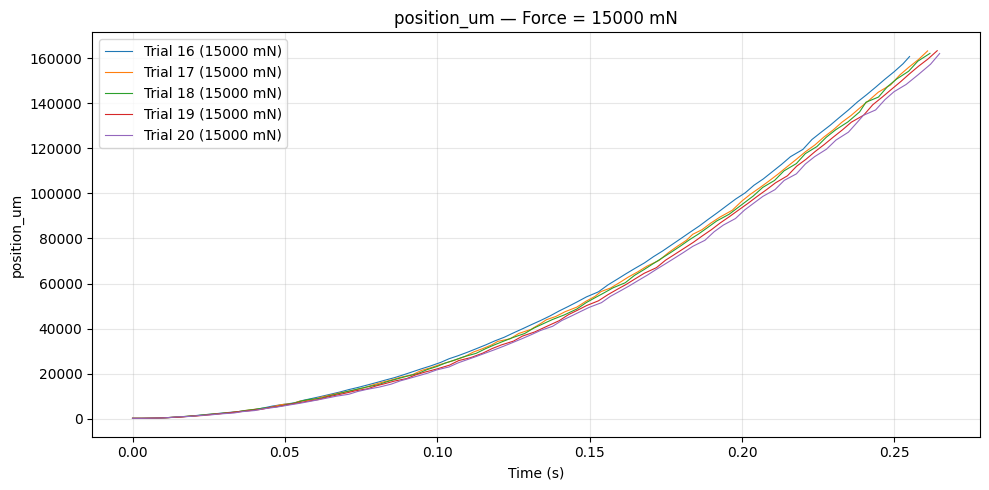

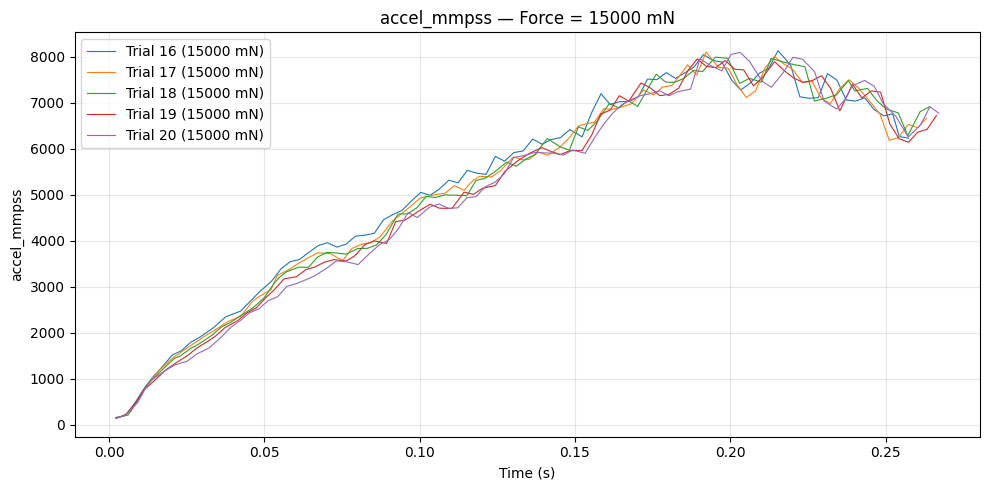

In [60]:
# ---------------------------------------------------------------------------
# Main — example usage
# ---------------------------------------------------------------------------

# 1) Single trial detail
trial_number = 14
# fig_single = plot_single_trial(trials[trial_number], title_suffix=f"(Trial {trial_number})")

# 2) Compare specific trials
# fig = plot_by_trial_numbers(trials, [1, 2, 3], field="position_um")
# fig = plot_by_trial_numbers(trials, [1, 2, 3], field="accel_mmpss")

# 3) All trials at a given force
_ = plot_by_force(index, trials, force_mN=15000, field="position_um")
_ = plot_by_force(index, trials, force_mN=15000, field="accel_mmpss")

# 4) Acceleration vs position
# _ = plot_accel_vs_position(trials, force_mN=12500)

# 5) Summary bar chart
# _ = plot_summary_stats(index, trials)

# Show all open figures
# plt.show()

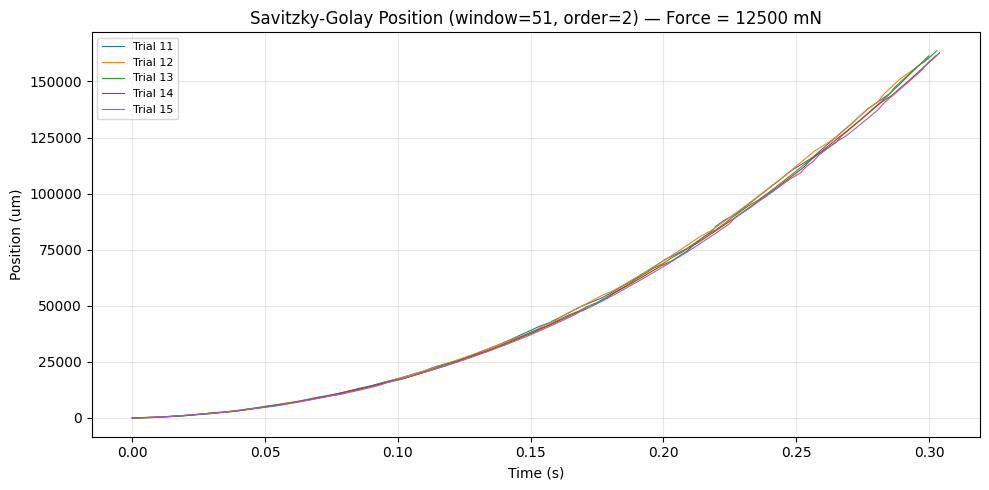

In [30]:
raw_acceleration_results, _ = plot_savgol_data(index,
                                               trials=trials,
                                               force_mN=12500,
                                               window=51,
                                               order=2,
                                               derivative=0
                                               )

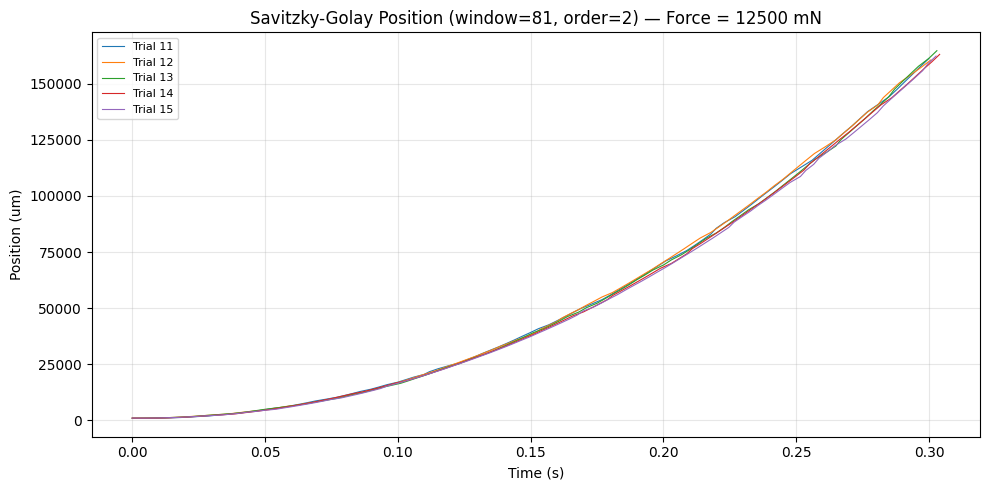

In [50]:
savgol_results, _ = plot_savgol_data(index,
                                     trials,
                                    force_mN=12500,
                                    window=81,
                                    order=2,
                                    derivative=0)

In [51]:
savgol_results.keys()

dict_keys([11, 12, 13, 14, 15])

In [58]:
trial_number = 12

df = trials[trial_number]
times_raw = df["t_stream_s"].values
pos_raw = df["position_um"].values.astype(np.float64)

times_from_filt = savgol_results[trial_number]['t']
filt_pos = savgol_results[trial_number]['Position_filtered']

calc_vels_from_raw = np.gradient(pos_raw, times_raw)
calc_vels_from_filt = np.gradient(savgol_results[trial_number]['Position_filtered'], savgol_results[trial_number]['t'])

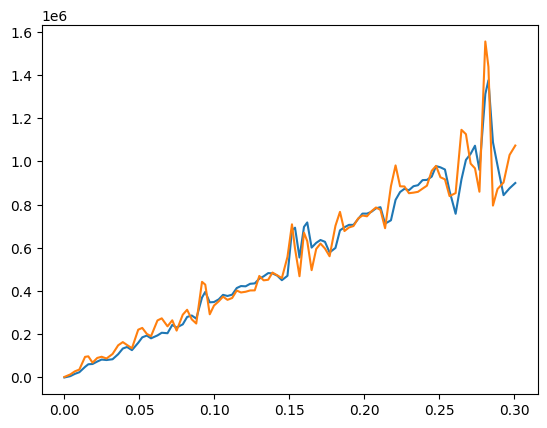

In [59]:
plt.plot(times_from_filt, calc_vels_from_filt)
plt.plot(times_raw, calc_vels_from_raw)